# lab 6 - Tasks
## Hashim Aljarrash---2230000215---8MA2

### Task 1

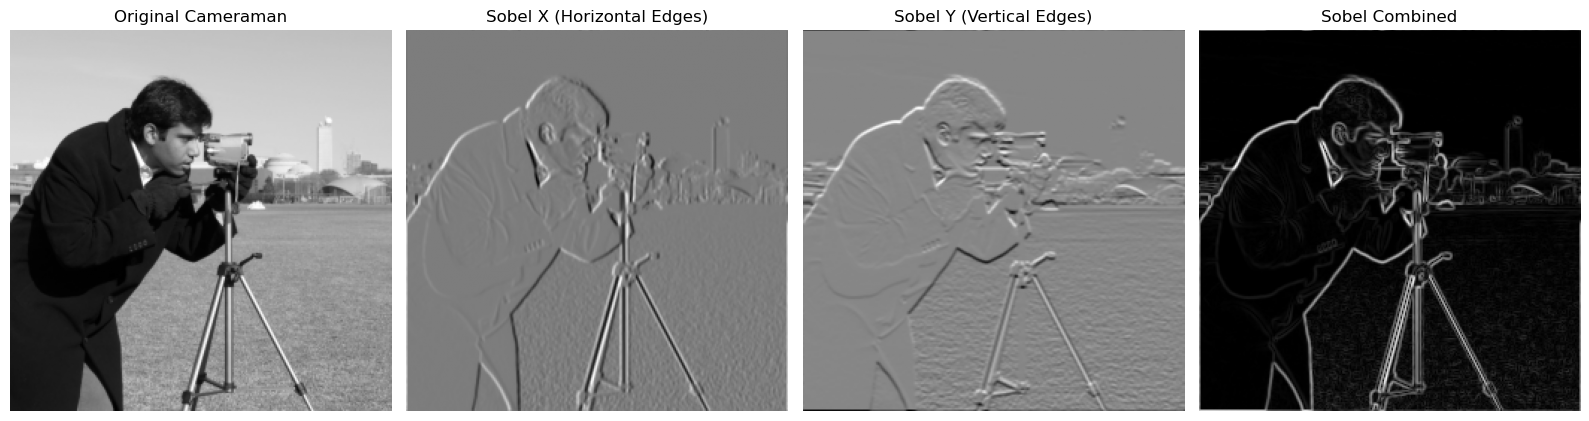

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

# Load and resize image
image = data.camera()
image = resize(image, (256, 256))

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))

# Compute FFT of image
F = fft2(image)

# FFT of centered Sobel filters
F_sobel_x = center_embed_kernel(sobel_x, image.shape)
F_sobel_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_filtered_x = F * F_sobel_x
F_filtered_y = F * F_sobel_y

# Inverse FFT to get spatial results
sobel_x_result = ifft2(F_filtered_x).real
sobel_y_result = ifft2(F_filtered_y).real

# Combined magnitude
sobel_combined = np.sqrt(sobel_x_result**2 + sobel_y_result**2)

# Plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(sobel_x_result, cmap='gray')
plt.title('Sobel X (Horizontal Edges)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(sobel_y_result, cmap='gray')
plt.title('Sobel Y (Vertical Edges)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined')
plt.axis('off')

plt.tight_layout()
plt.show()